# Actividad - Proyecto práctico


> La actividad se desarrollará en grupos pre-definidos de 4 alumnos. Se debe indicar los nombres en orden alfabético (de apellidos). Recordad que esta actividad se corresponde con un 30% de la nota final de la asignatura. Se debe entregar entregar el trabajo en la presente notebook.
*   Alumno 1: Emma Oitaven Carracedo
*   Alumno 2: Ramiro Rivas Fernández
*   Alumno 3: Víctor Rodríguez Rodríguez
*   Alumno 4: Nicolás Zamorano Ramírez






---
## **Preliminares** - Configuración del entorno

> Estas instrucciones documentan el proceso de configuración del entorno de trabajo en local con Windows + Miniconda + VS Code. El proyecto está pensado originalmente para Colab, pero la renderización de gym requiere ejecución en local.

### Pasos seguidos en local (Windows + Miniconda + VS Code)

Se ha creado un environment de conda con Python 3.8 e instalado las librerías en un orden controlado para evitar conflictos de dependencias (TensorFlow y Keras son especialmente sensibles a esto).

### Windows: 

```bash
# 1) Crear environment con Python 3.8 (requerido por gym 0.17.3)
conda create --name miar_rl python=3.8 -y
conda activate miar_rl

# 2) Herramientas base
python -m pip install --upgrade pip setuptools wheel

# 3) TensorFlow primero, fijado (evita que keras-rl2 arrastre una versión incompatible)
pip install tensorflow==2.5.3

# 4) Dependencias compatibles
pip install numpy==1.19.5 h5py==3.1.0 Pillow==9.5.0 pyglet==1.5.0
pip install gym==0.17.3

# 5) keras-rl2 sin dependencias (para que no pise TensorFlow)
pip install --no-deps keras-rl2==1.0.5

# 6) Kernel para VS Code
pip install ipykernel
python -m ipykernel install --user --name miar_rl --display-name "Python (miar_rl)"
```

### Mac: 


```bash 
# 1) Crear environment con Python 3.8 (requerido por gym 0.17.3):
conda create --name miar_rl python=3.8 -y
conda activate miar_rl

# 2) Installar las dependencias listadas en `requirements_mac.txt`
pip install -r requirements_mac.txt

# 3) Comprobar la depedencia de tensor flow: 
python -c "import tensorflow as tf; print(tf.__version__)"

# 4) Comprobar la dependencia de gym:
python -c "import gym; print(gym.__version__)"

# 5) Comprobar la dependencia de keras-rl2:
python -c "import rl; print('keras-rl2 OK')"

# 6) Comprobar el kernell de Jupyter:
python -m ipykernel install --user --name miar_rl --display-name "Python (miar_rl)"

```


Con esto, basta seleccionar el kernel **"Python (miar_rl)"** desde VS Code al abrir el notebook.

**Nota sobre el entorno Acrobot-v1 del Grupo 1**: al ser un entorno de *Classic Control* (no Atari), no requiere instalar `atari-py` ni gestionar ROMs.

---

In [1]:
import sys
from importlib.metadata import version, PackageNotFoundError

print("Python    :", sys.version.split()[0])

# Comprobación segura de TensorFlow en Mac
try:
    print("TensorFlow:", version("tensorflow-macos"))
except PackageNotFoundError:
    try:
        print("TensorFlow:", version("tensorflow"))
    except PackageNotFoundError:
        print("TensorFlow: ¡No instalado!")

# El resto de librerías
for pkg in ["gym", "keras-rl2", "numpy"]:
    try:
        print(f"{pkg:<10}: {version(pkg)}")
    except PackageNotFoundError:
        print(f"{pkg:<10}: ¡No instalado!")

Python    : 3.8.20
TensorFlow: 2.13.0
gym       : 0.25.2
keras-rl2 : 1.0.5
numpy     : 1.24.3


---
## **PARTE 1**. Enunciado

Consideraciones a tener en cuenta:

- El entorno sobre el que trabajaremos será el indicado en el listado correspondien de cada grupo y el algoritmo que usaremos será _DQN_.

- Para nuestro ejercicio, el requisito mínimo será alcanzado cuando el agente consiga una **media de recompensa por encima de los puntos indicados en el listado por grupos en modo test**. Por ello, esta media de la recompensa se calculará a partir del código de test en la última celda del notebook.

Este proyecto práctico consta de tres partes:

1.   Implementar la red neuronal que se usará en la solución
2.   Implementar las distintas piezas de la solución DQN y probar al menos 3 propuestas diferentes de mejora.
3.   Justificar la respuesta en relación a los resultados obtenidos e incluir al menos 3 gráficas relevantes comparando las 3 propuestas.

**Rúbrica**: Se valorará la originalidad en la solución aportada, así como la capacidad de discutir los resultados de forma detallada. El requisito mínimo servirá para aprobar la actividad, bajo premisa de que la discusión del resultado sera apropiada.

IMPORTANTE:

* Si no se consigue una puntuación óptima, responder sobre la mejor puntuación obtenida.
* Para entrenamientos largos, recordad que podéis usar checkpoints de vuestros modelos para retomar los entrenamientos. En este caso, recordad cambiar los parámetros adecuadamente (sobre todo los relacionados con el proceso de exploración).
* Se deberá entregar unicamente el notebook y los pesos del mejor modelo en un fichero .zip, de forma organizada.
* Cada alumno deberá de subir la solución de forma individual.

---
## **PARTE 2**. Desarrollo y preguntas

#### Importar librerías

In [2]:
# Comprobamos la versión de TensorFlow y si detecta la GPU de Apple Silicon
import tensorflow as tf
import keras

print("TF version:", tf.__version__)
print("Keras version:", keras.__version__)

# Esto buscará tanto GPUs tradicionales como la GPU Metal de tu Mac
gpus = tf.config.list_physical_devices('GPU')
print("Physical GPUs:", gpus)
print("Logical GPUs:", tf.config.list_logical_devices('GPU'))

# Validación final
if gpus:
    print("\nSe está usando la GPU para acelerar TensorFlow")
else:
    print("\nCuidado: Sigue usando solo la CPU. Revisa si instalaste tensorflow-metal.")

TF version: 2.13.0
Keras version: 2.13.1
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Logical GPUs: [LogicalDevice(name='/device:GPU:0', device_type='GPU')]

Se está usando la GPU para acelerar TensorFlow


2026-07-01 18:50:56.736258: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-07-01 18:50:56.736276: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-07-01 18:50:56.736283: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-07-01 18:50:56.736308: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-01 18:50:56.736320: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [4]:
from __future__ import division
import sys

# === MAC APPLE SILICON Y KERAS-RL2 ===
# Forzamos a Python a creer que keras tiene una versión dentro de tensorflow
import tensorflow as tf
import keras
if not hasattr(tf.keras, '__version__'):
    tf.keras.__version__ = keras.__version__
# ==========================================================

import numpy as np
import gym

# Imports de TensorFlow adaptados
from keras.models import Sequential
from keras.layers import Dense, Activation, Flatten
from keras.optimizers import legacy as legacy_optimizers
import keras.backend as K

# importamos keras-rl2 sin que se entere de que TF es moderno
from rl.agents.dqn import DQNAgent
from rl.policy import LinearAnnealedPolicy, BoltzmannQPolicy, EpsGreedyQPolicy
from rl.memory import SequentialMemory
from rl.core import Processor
from rl.callbacks import Callback, FileLogger, ModelIntervalCheckpoint

print("Todos los módulos cargados y listos para usar la GPU.")

Todos los módulos cargados y listos para usar la GPU.


In [5]:
import keras.optimizers, platform

# En Apple Silicon, keras.optimizers.get() detecta el chip ARM y convierte
# cualquier optimizador "nuevo" a su versión legacy. Esa conversión rompe el
# wrapper interno de keras-rl2 (AdditionalUpdatesOptimizer) -> acaba siendo
# un str -> 'str' object has no attribute 'get_updates'.
# Parcheamos la detección (solo afecta a rendimiento, no a la corrección)
# para que get() devuelva el optimizador sin tocarlo.
if platform.system() == "Darwin" and platform.machine() == "arm64":
    keras.optimizers.get.__globals__['is_arm_mac'] = lambda: False

# === DUELING (keras-rl2) + TF moderno ===
# Al activar enable_dueling_network, keras-rl2 inyecta una capa Lambda y, al
# clonar el modelo para el target network, TF 2.12+ se niega por defecto a
# deserializar lambdas de Python (safe_mode=True) -> ValueError. Como el modelo
# es nuestro, habilitamos la deserializacion. En TF antiguo este mecanismo no
# existe, asi que el try/except lo deja en no-op (portable a Windows).
try:
    from keras.saving.serialization_lib import enable_unsafe_deserialization
    enable_unsafe_deserialization()
except Exception:
    try:
        from keras.src.saving.serialization_lib import enable_unsafe_deserialization
        enable_unsafe_deserialization()
    except Exception:
        pass


#### Configuración base

In [6]:
# Configuración base para Acrobot-v1
env_name = 'Acrobot-v1'
env = gym.make(env_name)

np.random.seed(123)
env.seed(123)

INPUT_SHAPE = env.observation_space.shape   # (6,) — vector de estado, no imagen
WINDOW_LENGTH = 1                            # Acrobot es Markov puro
nb_actions = env.action_space.n              # 3 acciones: torque {-1, 0, +1}

print(f"Entorno: {env_name}")
print(f"Espacio de observación: {env.observation_space}")
print(f"Espacio de acciones: {env.action_space} -> {nb_actions} acciones")
print(f"INPUT_SHAPE: {INPUT_SHAPE}, WINDOW_LENGTH: {WINDOW_LENGTH}")

Entorno: Acrobot-v1
Espacio de observación: Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
Espacio de acciones: Discrete(3) -> 3 acciones
INPUT_SHAPE: (6,), WINDOW_LENGTH: 1


/opt/anaconda3/envs/miar_rl/lib/python3.8/site-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/opt/anaconda3/envs/miar_rl/lib/python3.8/site-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/opt/anaconda3/envs/miar_rl/lib/python3.8/site-packages/gym/core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


In [7]:
class AcrobotProcessor(Processor):
    """Procesador para Acrobot-v1.
    
    Normaliza las dos velocidades angulares dividiéndolas por su rango máximo
    (4π y 9π rad/s respectivamente) para que todo el vector de observación
    quede en [-1, 1]. Las 4 primeras componentes (cos/sin de los ángulos)
    ya están naturalmente en ese rango.
    
    No procesa imágenes (la observación es un vector de 6 floats) ni recorta
    la recompensa (que ya está acotada en {-1, 0} por el propio entorno).
    """
    
    THETA1_DOT_MAX = 4 * np.pi   # ≈ 12.566 rad/s, rango de la 5ª componente
    THETA2_DOT_MAX = 9 * np.pi   # ≈ 28.274 rad/s, rango de la 6ª componente

    def process_observation(self, observation):
        assert observation.shape == (6,)
        obs = np.asarray(observation, dtype=np.float32).copy()
        obs[4] /= self.THETA1_DOT_MAX
        obs[5] /= self.THETA2_DOT_MAX
        return obs

    def process_state_batch(self, batch):
        # El batch ya viene normalizado desde process_observation.
        # Solo aseguramos dtype float32 para el modelo Keras.
        return batch.astype('float32')

    # process_reward NO se redefine: la recompensa nativa de Acrobot
    # ya está en {-1, 0}, no necesita clipping ni transformación.

1. Implementación de la red neuronal

In [8]:
def build_q_model(input_shape, nb_actions, window_length=1):
    """Construye la red Q(s, a) para Acrobot.
    
    Arquitectura MLP 6 → 64 → 64 → 3 con activaciones ReLU.
    
    IMPORTANTE: Dense y Activation están combinados (no separados) para que
    model.layers[-2] sea la última capa densa de features (64 neuronas).
    Esto es requisito de keras-rl2 para que enable_dueling_network funcione
    correctamente, ya que el agente reemplaza todo lo que viene después de
    layers[-2] por las cabezas V(s) y A(s,a).
    """
    model = Sequential()
    model.add(Flatten(input_shape=(window_length,) + input_shape))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(128, activation='relu'))   # <- layers[-2]: features para Dueling
    model.add(Dense(nb_actions, activation='linear'))  # <- layers[-1]: Q-valores
    return model

# Verificación de la arquitectura. Usamos una semilla aislada (99) para que
# este demo no consuma la aleatoriedad de TF que luego usarán los entrenamientos.
tf.random.set_seed(99)
_demo_model = build_q_model(INPUT_SHAPE, nb_actions, WINDOW_LENGTH)
print(_demo_model.summary())
print(f"\nlayers[-2] = {_demo_model.layers[-2].name} "
      f"(output shape: {_demo_model.layers[-2].output_shape})")
del _demo_model

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 6)                 0         
                                                                 
 dense (Dense)               (None, 128)               896       
                                                                 
 dense_1 (Dense)             (None, 128)               16512     
                                                                 
 dense_2 (Dense)             (None, 3)                 387       
                                                                 
Total params: 17795 (69.51 KB)
Trainable params: 17795 (69.51 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None

layers[-2] = dense_1 (output shape: (None, 128))


2. Implementación de la solución DQN

In [9]:
# Dada las diferencias entre las versiones de TensorFlow
from packaging.version import Version

def make_adam(lr=1e-3):
    """Adam compatible con keras-rl2 según la versión de TensorFlow."""
    if Version(tf.__version__) >= Version("2.11"):
        # TF 2.11+: el Adam por defecto rompe keras-rl2 -> usar el legacy
        from tensorflow.keras.optimizers.legacy import Adam
    else:
        # TF < 2.11: el Adam clásico ya es compatible (tiene _name)
        from tensorflow.keras.optimizers import Adam
    return Adam(learning_rate=lr)


In [10]:
def build_agent(model, processor,
                enable_double_dqn=False,
                enable_dueling_network=False,
                dueling_type='avg'):
    """Construye un DQNAgent configurable.
    
    Los hiperparámetros base son idénticos para las 4 configuraciones del
    estudio; sólo varían los dos flags enable_double_dqn y enable_dueling_network.
    """
    memory = SequentialMemory(limit=100000, window_length=WINDOW_LENGTH)
    
    policy = LinearAnnealedPolicy(
        EpsGreedyQPolicy(),
        attr='eps',
        value_max=1.0,    # exploración inicial total
        value_min=0.02,   # exploración residual al final
        value_test=0.0,   # greedy puro en test
        nb_steps=40000    # decaimiento lineal durante los primeros 10k steps
    )
    
    dqn = DQNAgent(
        model=model,
        nb_actions=nb_actions,
        memory=memory,
        processor=processor,
        policy=policy,
        nb_steps_warmup=4000,
        gamma=0.99,
        target_model_update=1e-2,   # soft update (Polyak)
        train_interval=4,
        batch_size=64,
        enable_double_dqn=enable_double_dqn,
        enable_dueling_network=enable_dueling_network,
        dueling_type=dueling_type,
    )
    #dqn.compile(Adam(learning_rate=1e-3), metrics=['mae'])
    dqn.compile(make_adam(2.5e-4), metrics=['mae'])
    return dqn

In [11]:
import os
from rl.callbacks import Callback

NB_TRAIN_STEPS = 100000
LOG_DIR = 'logs'
WEIGHTS_DIR = 'weights'
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)


class RenderEveryNSteps(Callback):
    """Cada N pasos de entrenamiento, ejecuta un episodio greedy con render
    en ventana de pyglet para visualizar cualitativamente el progreso del agente.
    
    Usa predicción directa del modelo (argmax sobre Q-valores) en lugar de
    self.model.forward(), para no interferir con el estado interno del agente
    durante el entrenamiento y para mostrarlo siempre en modo greedy puro.
    """
    def __init__(self, env_name, interval=20000, max_steps=500, seed=42):
        self.env_name = env_name
        self.interval = interval
        self.max_steps = max_steps
        self.seed = seed
        self.next_render_at = interval
    
    def on_step_end(self, step, logs={}):
        if self.model.step >= self.next_render_at:
            self.next_render_at += self.interval
            try:
                self._demo()
            except Exception as e:
                # Una demo fallida (p.ej. backend de render ausente) NUNCA
                # debe tumbar un entrenamiento largo.
                print(f"\n  [Demo omitida en paso {self.model.step}: {e}]")
    
    def _demo(self):
        print(f"\n  [Demo en vivo en paso {self.model.step}]")
        env_demo = gym.make(self.env_name)
        env_demo.seed(self.seed)
        obs = env_demo.reset()
        processor = self.model.processor
        total = 0
        for _ in range(self.max_steps):
            env_demo.render()
            # Predicción greedy directa, sin tocar el estado del agente
            proc_obs = processor.process_observation(obs) if processor else obs
            batch = np.array([[proc_obs]]).astype('float32')
            q_values = self.model.model.predict(batch, verbose=0)[0]
            action = int(np.argmax(q_values))
            obs, r, done, _ = env_demo.step(action)
            total += r
            if done:
                break
        env_demo.close()
        print(f"  [Demo: reward = {total:.0f}]")


def train_config(config_name, **agent_kwargs):
    """Entrena una configuración de DQN sobre Acrobot-v1.
    
    Devuelve (dqn, history) y guarda en disco:
      - logs/dqn_<config>_log.json   : log episodio a episodio (para gráficas)
      - weights/dqn_<config>_weights.h5f : pesos finales del modelo
    """
    print(f"\n{'='*60}\n  Entrenando configuración: {config_name}\n{'='*60}")
    
    # Control completo de semillas: numpy + tensorflow + entorno.
    # tf.random.set_seed garantiza que cada config arranca con LOS MISMOS
    # pesos iniciales en la red, eliminando la varianza por inicialización.
    SEED = 123
    np.random.seed(SEED)
    tf.random.set_seed(SEED)
    env_local = gym.make(env_name)
    env_local.seed(SEED)
    
    # Cada config construye su propia red (con pesos reproducibles por la seed)
    model = build_q_model(INPUT_SHAPE, nb_actions, WINDOW_LENGTH)
    processor = AcrobotProcessor()
    dqn = build_agent(model, processor, **agent_kwargs)
    
    log_filename = os.path.join(LOG_DIR, f'dqn_{config_name}_log.json')
    weights_filename = os.path.join(WEIGHTS_DIR, f'dqn_{config_name}_weights.h5f')
    
    callbacks = [
        FileLogger(log_filename, interval=100),
        RenderEveryNSteps(env_name, interval=20000, max_steps=500),
    ]
    
    history = dqn.fit(env_local, nb_steps=NB_TRAIN_STEPS,
                      callbacks=callbacks,
                      log_interval=10000,
                      visualize=False, verbose=1)
    
    dqn.save_weights(weights_filename, overwrite=True)
    print(f"\n[OK] Pesos guardados en {weights_filename}")
    print(f"[OK] Log guardado en {log_filename}")
    
    return dqn, history

In [12]:
# Configuración 1: DQN baseline (vanilla)
dqn_baseline, hist_baseline = train_config(
    'baseline'
)

# Configuración 2: Double DQN
dqn_double, hist_double = train_config(
    'double',
    enable_double_dqn=True
)

# Configuración 3: Dueling DQN
dqn_dueling, hist_dueling = train_config(
    'dueling',
    enable_dueling_network=True,
    dueling_type='avg'
)

# Configuración 4: Double + Dueling DQN
dqn_double_dueling, hist_double_dueling = train_config(
    'double_dueling',
    enable_double_dqn=True,
    enable_dueling_network=True,
    dueling_type='avg'
)

print("\n[OK] Entrenamiento completado para las 4 configuraciones.")

2026-07-01 18:51:13.922536: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-01 18:51:13.922554: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-07-01 18:51:13.925780: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:375] MLIR V1 optimization pass is not enabled
2026-07-01 18:51:13.928108: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-07-01 18:51:13.936231: W tensorflow/c/c_api.cc:304] Operation '{name:'dense_5_1/bias/Assign' id:218 op device:{requested: '', assigned: ''} def:{{{node dense_5_1/bias/Assign}} = AssignVariableOp


  Entrenando configuración: baseline
Training for 100000 steps ...
Interval 1 (0 steps performed)


/opt/anaconda3/envs/miar_rl/lib/python3.8/site-packages/keras/src/engine/training_v1.py:2359: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,
2026-07-01 18:51:14.084690: W tensorflow/c/c_api.cc:304] Operation '{name:'dense_5/BiasAdd' id:149 op device:{requested: '', assigned: ''} def:{{{node dense_5/BiasAdd}} = BiasAdd[T=DT_FLOAT, _has_manual_control_dependencies=true, data_format="NHWC"](dense_5/MatMul, dense_5/BiasAdd/ReadVariableOp)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2026-07-01 18:51:14.088090: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-07-01 18:51:14.091563: W tensorflow/c/c_a

  117/10000 [..............................] - ETA: 8s - reward: -1.0000 

/opt/anaconda3/envs/miar_rl/lib/python3.8/site-packages/gym/utils/passive_env_checker.py:241: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


...

2026-07-01 19:10:19.694706: W tensorflow/c/c_api.cc:304] Operation '{name:'lambda_1_2/sub' id:2686 op device:{requested: '', assigned: ''} def:{{{node lambda_1_2/sub}} = Sub[T=DT_FLOAT, _has_manual_control_dependencies=true](lambda_1_2/add, lambda_1_2/Mean)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2026-07-01 19:10:19.712957: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-07-01 19:10:19.768812: W tensorflow/c/c_api.cc:304] Operation '{name:'loss_15/AddN' id:2948 op device:{requested: '', assigned: ''} def:{{{node loss_15/AddN}} = AddN[N=2, T=DT_FLOAT, _has_manual_control_dependencies=true](loss_15/mul, loss_15/mul_1)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger 

 4033/10000 [===========>..................] - ETA: 6s - reward: -1.0000

2026-07-01 19:10:19.996833: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-07-01 19:10:20.025258: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-07-01 19:10:20.053082: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-07-01 19:10:20.081577: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


10000/10000 [==============================] - 24s 2ms/step - reward: -0.9999
20 episodes - episode_reward: -493.600 [-500.000, -372.000] - loss: 0.130 - mae: 4.846 - mean_q: -7.054 - mean_eps: 0.829

Interval 2 (10000 steps performed)
10000/10000 [==============================] - 32s 3ms/step - reward: -0.9996
21 episodes - episode_reward: -462.714 [-500.000, -235.000] - loss: 0.677 - mae: 14.470 - mean_q: -21.219 - mean_eps: 0.633

Interval 3 (20000 steps performed)

  [Demo en vivo en paso 20000]
  [Demo: reward = -500]
10000/10000 [==============================] - 66s 3ms/step - reward: -0.9982
26 episodes - episode_reward: -384.115 [-500.000, -130.000] - loss: 1.768 - mae: 23.592 - mean_q: -34.519 - mean_eps: 0.388

Interval 4 (30000 steps performed)
10000/10000 [==============================] - 33s 3ms/step - reward: -0.9967
36 episodes - episode_reward: -287.000 [-500.000, -110.000] - loss: 3.368 - mae: 29.627 - mean_q: -43.086 - mean_eps: 0.143

Interval 5 (40000 steps perfo

2026-07-01 19:16:48.765144: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


In [13]:
# Evaluación de las 4 configuraciones sobre 100 episodios de test
TEST_EPISODES = 100

def evaluate(dqn, name, seed=123):
    print(f"\n--- Evaluando: {name} ---")
    # Resetear semillas antes de CADA test para que las 4 configs vean
    # exactamente los mismos 100 episodios (comparativa justa).
    env.seed(seed)
    np.random.seed(seed)
    history = dqn.test(env, nb_episodes=TEST_EPISODES, visualize=False, verbose=0)
    rewards = np.array(history.history['episode_reward'])
    steps = np.array(history.history['nb_steps'])
    solved = int(np.sum(rewards > -500))
    print(f"  Recompensa media   : {rewards.mean():.2f} ± {rewards.std():.2f}")
    print(f"  Recompensa min/max : {rewards.min():.0f} / {rewards.max():.0f}")
    print(f"  Pasos medios/epis. : {steps.mean():.1f}")
    print(f"  Episodios resueltos: {solved}/{TEST_EPISODES} "
          f"({100*solved/TEST_EPISODES:.0f}%)")
    return rewards

rewards_baseline       = evaluate(dqn_baseline,       'DQN baseline')
rewards_double         = evaluate(dqn_double,         'Double DQN')
rewards_dueling        = evaluate(dqn_dueling,        'Dueling DQN')
rewards_double_dueling = evaluate(dqn_double_dueling, 'Double + Dueling DQN')


--- Evaluando: DQN baseline ---
  Recompensa media   : -98.48 ± 20.38
  Recompensa min/max : -166 / -66
  Pasos medios/epis. : 99.5
  Episodios resueltos: 100/100 (100%)

--- Evaluando: Double DQN ---
  Recompensa media   : -500.00 ± 0.00
  Recompensa min/max : -500 / -500
  Pasos medios/epis. : 500.0
  Episodios resueltos: 0/100 (0%)

--- Evaluando: Dueling DQN ---
  Recompensa media   : -500.00 ± 0.00
  Recompensa min/max : -500 / -500
  Pasos medios/epis. : 500.0
  Episodios resueltos: 0/100 (0%)

--- Evaluando: Double + Dueling DQN ---
  Recompensa media   : -216.33 ± 30.36
  Recompensa min/max : -297 / -152
  Pasos medios/epis. : 217.3
  Episodios resueltos: 100/100 (100%)


In [14]:
from PIL import Image
from IPython.display import Image as IPyImage, display

def record_episode_gif(dqn, env_name, gif_path, max_steps=500, fps=30):
    """Ejecuta un episodio greedy y guarda los frames como GIF animado.
    
    Devuelve (reward_total, n_steps, success) y muestra el GIF inline.
    """
    env_rec = gym.make(env_name)
    env_rec.seed(42)
    obs = env_rec.reset()
    
    frames = []
    total_reward = 0.0
    for step in range(max_steps):
        frame = env_rec.render(mode='rgb_array')
        frames.append(Image.fromarray(frame))
        
        # Política greedy del agente entrenado
        action = dqn.forward(obs)
        obs, reward, done, _ = env_rec.step(action)
        total_reward += reward
        if done:
            # Capturar también el frame final
            frames.append(Image.fromarray(env_rec.render(mode='rgb_array')))
            break
    env_rec.close()
    
    # Guardar GIF
    frames[0].save(
        gif_path,
        save_all=True,
        append_images=frames[1:],
        duration=int(1000 / fps),
        loop=0,
        optimize=True,
    )
    
    success = total_reward > -500
    print(f"Episodio: {step+1} pasos, reward = {total_reward:.1f}, "
          f"{'ÉXITO ✓' if success else 'fallo ✗'}")
    print(f"GIF guardado en: {gif_path}")
    display(IPyImage(filename=gif_path))
    return total_reward, step + 1, success

=== Demostración: DQN baseline ===


/opt/anaconda3/envs/miar_rl/lib/python3.8/site-packages/gym/core.py:43: DeprecationWarning: WARN: The argument mode in render method is deprecated; use render_mode during environment initialization instead.
See here for more information: https://www.gymlibrary.ml/content/api/
  deprecation(


Episodio: 81 pasos, reward = -80.0, ÉXITO ✓
GIF guardado en: gifs/baseline.gif


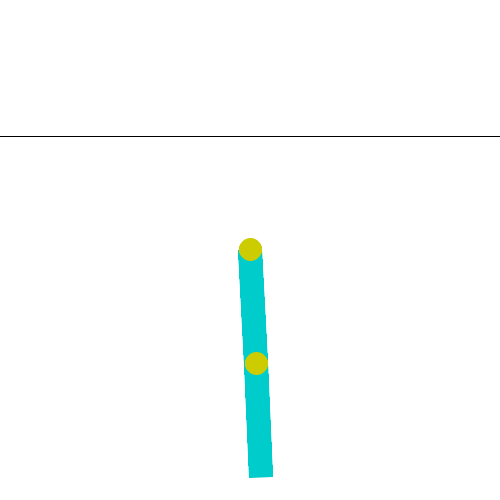


=== Demostración: Double DQN ===
Episodio: 388 pasos, reward = -387.0, ÉXITO ✓
GIF guardado en: gifs/double.gif


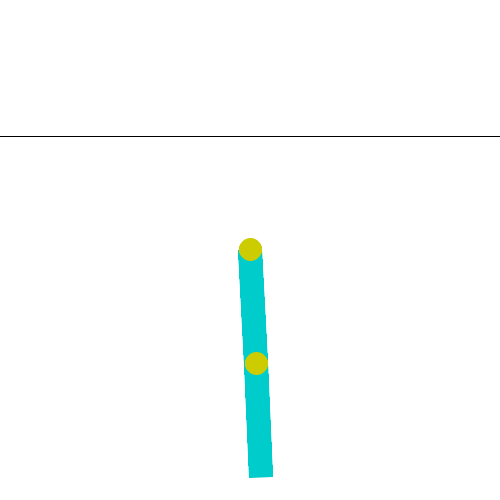


=== Demostración: Dueling DQN ===
Episodio: 500 pasos, reward = -500.0, fallo ✗
GIF guardado en: gifs/dueling.gif


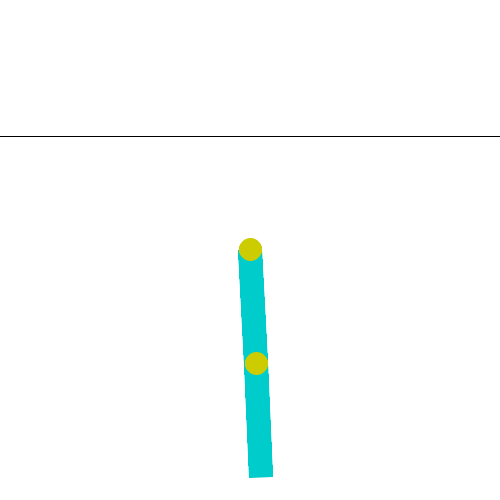


=== Demostración: Double + Dueling DQN ===
Episodio: 103 pasos, reward = -102.0, ÉXITO ✓
GIF guardado en: gifs/double_dueling.gif


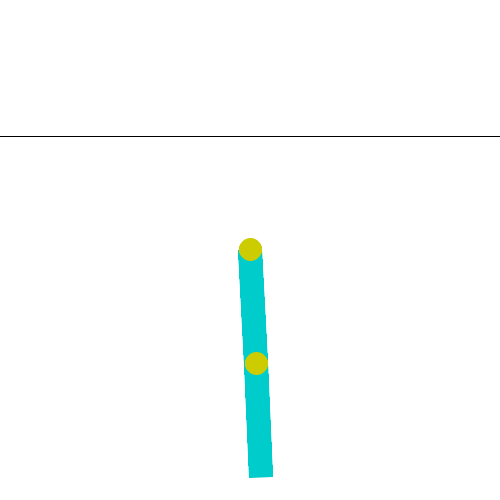

(-102.0, 103, True)

In [15]:
os.makedirs('gifs', exist_ok=True)

print("=== Demostración: DQN baseline ===")
record_episode_gif(dqn_baseline, env_name, 'gifs/baseline.gif')

print("\n=== Demostración: Double DQN ===")
record_episode_gif(dqn_double, env_name, 'gifs/double.gif')

print("\n=== Demostración: Dueling DQN ===")
record_episode_gif(dqn_dueling, env_name, 'gifs/dueling.gif')

print("\n=== Demostración: Double + Dueling DQN ===")
record_episode_gif(dqn_double_dueling, env_name, 'gifs/double_dueling.gif')

In [16]:
# === Setup para las gráficas comparativas ===
import json
import matplotlib.pyplot as plt
import matplotlib as mpl

# Estilo global de las gráficas
plt.style.use('seaborn-whitegrid' if 'seaborn-whitegrid' in plt.style.available else 'default')
mpl.rcParams.update({
    'figure.dpi': 100,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})

# Mapeo unificado de colores y etiquetas (consistente entre las 3 gráficas)
CONFIGS = {
    'baseline':       {'label': 'DQN baseline',         'color': '#7f7f7f'},
    'double':         {'label': 'Double DQN',           'color': '#1f77b4'},
    'dueling':        {'label': 'Dueling DQN',          'color': '#2ca02c'},
    'double_dueling': {'label': 'Double + Dueling DQN', 'color': '#d62728'},
}

# Cargar los logs JSON generados por FileLogger durante el entrenamiento
LOGS = {}
for cfg in CONFIGS:
    with open(f'logs/dqn_{cfg}_log.json', 'r') as f:
        LOGS[cfg] = json.load(f)

# Resumen de lo que se ha cargado
for cfg, log in LOGS.items():
    print(f"  {cfg:18s}: {len(log['episode'])} episodios, "
          f"{log['nb_steps'][-1]:>6} pasos totales")


def smooth(y, window=10):
    """Media móvil simple para suavizar curvas ruidosas (el reward episodio a episodio
    tiene mucha varianza, y el suavizado revela la tendencia subyacente)."""
    y = np.asarray(y, dtype=float)
    if len(y) < window:
        return y
    box = np.ones(window) / window
    return np.convolve(y, box, mode='valid')


# Crear carpeta para guardar las gráficas como PNG (útil para incluirlas
# en informes externos, además de mostrarlas inline en el notebook)
os.makedirs('plots', exist_ok=True)

  baseline          : 450 episodios,  99945 pasos totales
  double            : 359 episodios,  99881 pasos totales
  dueling           : 481 episodios,  99837 pasos totales
  double_dueling    : 381 episodios,  99898 pasos totales


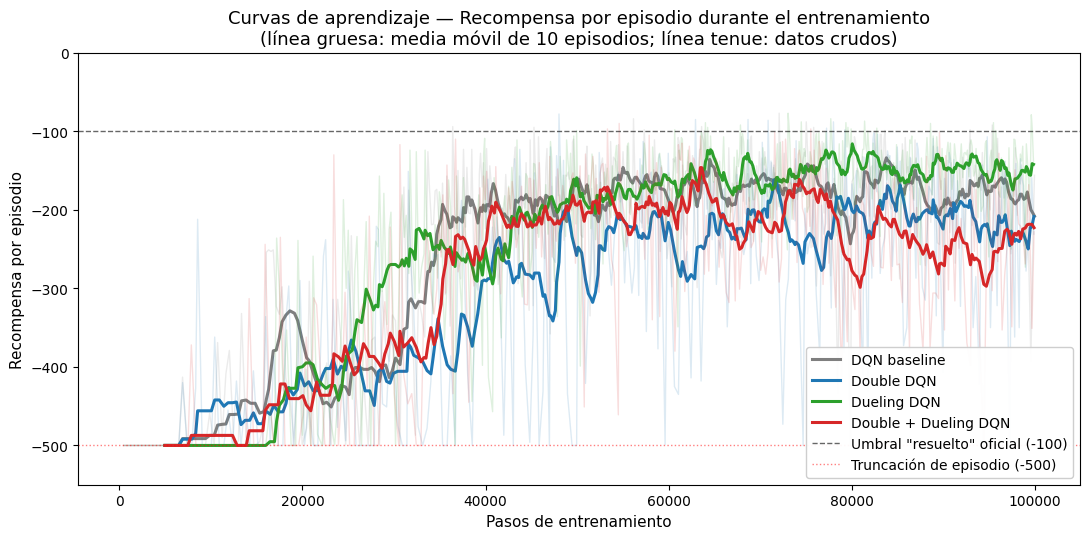

In [17]:
# === Gráfica 1: Curvas de aprendizaje (recompensa por episodio) ===
fig, ax = plt.subplots(figsize=(11, 5.5))

W = 10  # ventana de suavizado en episodios

for cfg, meta in CONFIGS.items():
    log = LOGS[cfg]
    steps = np.asarray(log['nb_steps'])
    rewards = np.asarray(log['episode_reward'])
    
    # Datos crudos en transparencia (muestran la varianza real episodio a episodio)
    ax.plot(steps, rewards, color=meta['color'], alpha=0.15, linewidth=1)
    
    # Curva suavizada destacada (revela la tendencia de aprendizaje)
    if len(rewards) >= W:
        smoothed = smooth(rewards, W)
        steps_smooth = steps[W-1:]
        ax.plot(steps_smooth, smoothed, color=meta['color'],
                linewidth=2.2, label=meta['label'])

# Líneas de referencia
ax.axhline(-100, color='black', linestyle='--', linewidth=1, alpha=0.6,
           label='Umbral "resuelto" oficial (-100)')
ax.axhline(-500, color='red', linestyle=':', linewidth=1, alpha=0.5,
           label='Truncación de episodio (-500)')

ax.set_xlabel('Pasos de entrenamiento')
ax.set_ylabel('Recompensa por episodio')
ax.set_title('Curvas de aprendizaje — Recompensa por episodio durante el entrenamiento\n'
             '(línea gruesa: media móvil de 10 episodios; línea tenue: datos crudos)')
ax.legend(loc='lower right', framealpha=0.95)
ax.set_ylim(-550, 0)
plt.tight_layout()
plt.savefig('plots/01_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()

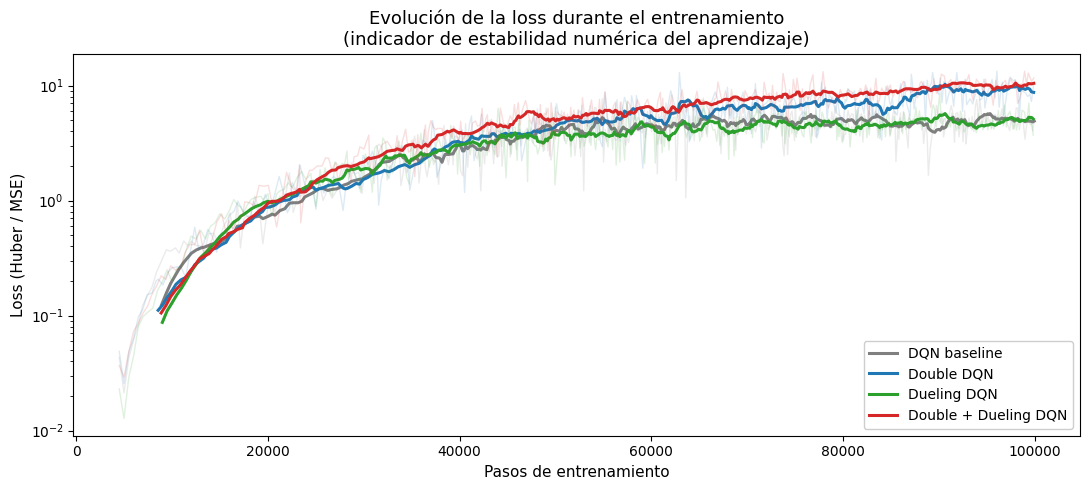

In [18]:
# === Gráfica 2: Evolución de la loss durante el entrenamiento ===
fig, ax = plt.subplots(figsize=(11, 5))

W = 10

for cfg, meta in CONFIGS.items():
    log = LOGS[cfg]
    steps = np.asarray(log['nb_steps'])
    losses = np.asarray(log['loss'])
    
    # Filtrar posibles NaN (ocurren en los primeros episodios antes del warmup)
    mask = ~np.isnan(losses)
    steps_v, losses_v = steps[mask], losses[mask]
    
    ax.plot(steps_v, losses_v, color=meta['color'], alpha=0.15, linewidth=1)
    if len(losses_v) >= W:
        ax.plot(steps_v[W-1:], smooth(losses_v, W), color=meta['color'],
                linewidth=2.2, label=meta['label'])

ax.set_xlabel('Pasos de entrenamiento')
ax.set_ylabel('Loss (Huber / MSE)')
ax.set_title('Evolución de la loss durante el entrenamiento\n'
             '(indicador de estabilidad numérica del aprendizaje)')
ax.legend(loc='lower right', framealpha=0.95)
ax.set_yscale('log')  # escala logarítmica porque la loss crece varios órdenes de magnitud
plt.tight_layout()
plt.savefig('plots/02_loss_curves.png', dpi=120, bbox_inches='tight')
plt.show()

/var/folders/vb/5s0zw4d926z6p33x52hjcp_40000gn/T/ipykernel_47369/177016440.py:55: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


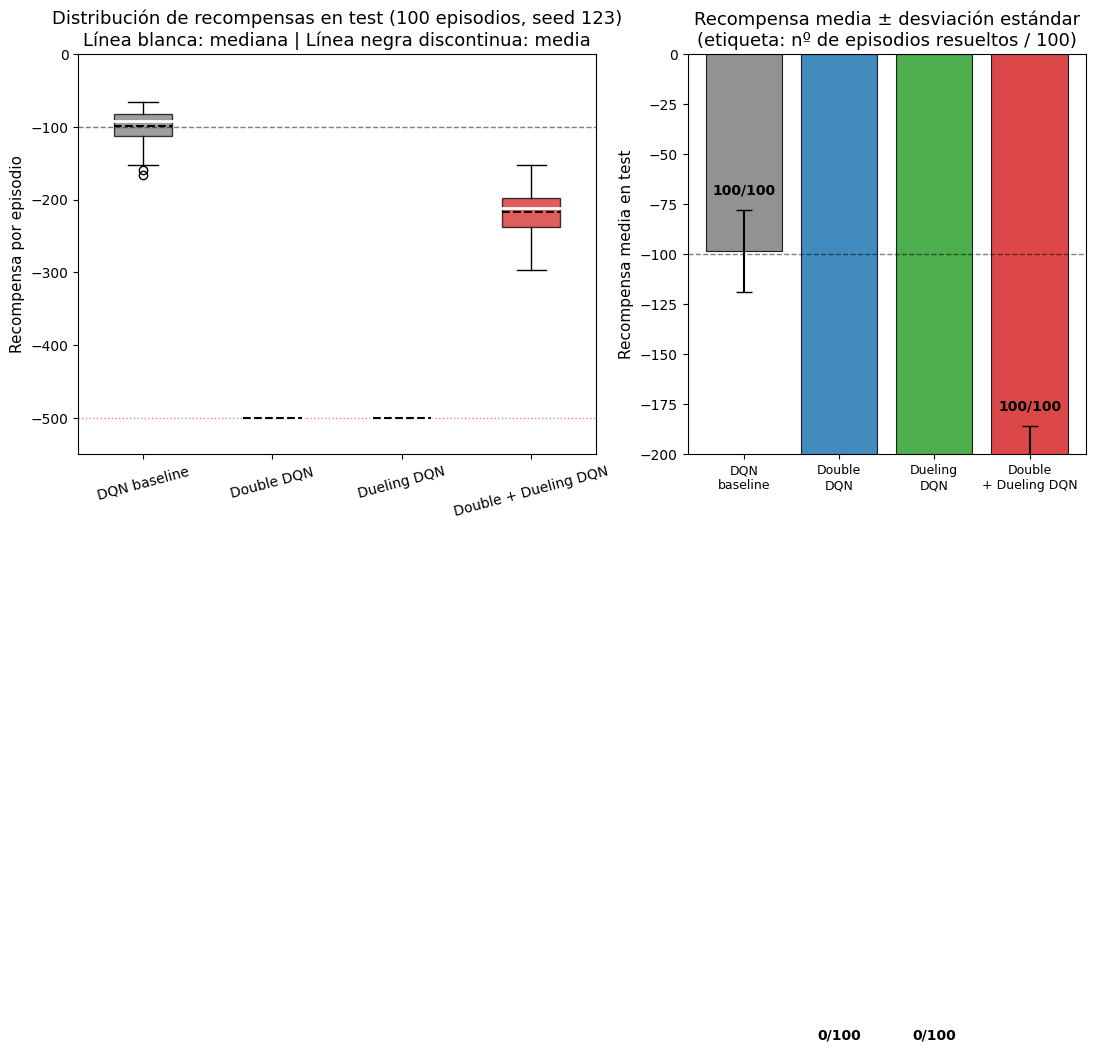

In [19]:
# === Gráfica 3: Distribución de recompensas en los 100 episodios de test ===
fig, (ax_box, ax_bar) = plt.subplots(1, 2, figsize=(13, 5.2),
                                       gridspec_kw={'width_ratios': [1.3, 1]})

# --- Panel izquierdo: boxplot ---
data_test = {
    'baseline':       rewards_baseline,
    'double':         rewards_double,
    'dueling':        rewards_dueling,
    'double_dueling': rewards_double_dueling,
}
labels = [CONFIGS[c]['label'] for c in data_test]
colors = [CONFIGS[c]['color']  for c in data_test]
values = [data_test[c] for c in data_test]

bp = ax_box.boxplot(values, labels=labels, patch_artist=True,
                    showmeans=True, meanline=True,
                    meanprops={'color': 'black', 'linewidth': 1.5, 'linestyle': '--'},
                    medianprops={'color': 'white', 'linewidth': 2})

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax_box.axhline(-100, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax_box.axhline(-500, color='red', linestyle=':', linewidth=1, alpha=0.5)
ax_box.set_ylabel('Recompensa por episodio')
ax_box.set_title('Distribución de recompensas en test (100 episodios, seed 123)\n'
                 'Línea blanca: mediana | Línea negra discontinua: media')
ax_box.tick_params(axis='x', rotation=15)
ax_box.set_ylim(-550, 0)

# --- Panel derecho: barras de métricas clave ---
means     = [v.mean() for v in values]
stds      = [v.std()  for v in values]
solved    = [int(np.sum(v > -500)) for v in values]

x = np.arange(len(labels))
bars = ax_bar.bar(x, means, yerr=stds, color=colors, alpha=0.85,
                  capsize=6, edgecolor='black', linewidth=0.8)
ax_bar.axhline(-100, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels([CONFIGS[c]['label'].replace(' ', '\n', 1) for c in data_test],
                       fontsize=9)
ax_bar.set_ylabel('Recompensa media en test')
ax_bar.set_title('Recompensa media ± desviación estándar\n'
                 '(etiqueta: nº de episodios resueltos / 100)')
ax_bar.set_ylim(-200, 0)

# Anotaciones encima de las barras: episodios resueltos
for bar, m, s, sv in zip(bars, means, stds, solved):
    ax_bar.text(bar.get_x() + bar.get_width()/2, m + s + 8,
                f'{sv}/100', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/03_test_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

3. Justificación de los parámetros seleccionados y de los resultados obtenidos

---